# Movie Recommendation System — Collaborative Filtering
### A complete walkthrough: Design → Train → Test → Validate → Measure

This notebook is the teaching companion to the `src/` code in this repository.
Every section below corresponds to one phase of the AI/ML project pipeline.

**Algorithm used:** User-Based Collaborative Filtering (built from scratch using cosine similarity)

**Dataset:** A small synthetic movie-ratings dataset (60 users, 45 movies, ~1000 ratings),
generated by `data/generate_dataset.py` so the whole notebook runs offline, instantly,
with no downloads or logins required.


In [1]:
# Make sure we can import from the src/ folder
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_raw_data, basic_stats, build_user_item_matrix
from src.train_test_split import train_test_split_per_user
from src.collaborative_filtering import UserBasedCF
from src.baseline import PopularityRecommender
from src.evaluate import rmse_mae, precision_recall_at_k, print_evaluation_report

pd.set_option('display.max_columns', 10)


## Step 1 — Load the Data
Raw ratings look like `(user_id, movie_id, rating, timestamp)` — one row per rating.
This is called "long format".

In [2]:
ratings_df, movies_df = load_raw_data("../data/ratings.csv", "../data/movies.csv")
print(ratings_df.shape, movies_df.shape)
ratings_df.head()

(1004, 4) (45, 3)


,user_id,movie_id,rating,timestamp
0,1,22,3,1609161408
1,1,11,3,1602042999
2,1,1,3,1601935740
3,1,21,3,1603434955
4,1,41,3,1603763122


In [3]:
movies_df.head()

,movie_id,title,genre
0,1,Iron Sky,Comedy
1,2,Laugh Track,Comedy
2,3,Silent Tears,Action
3,4,Star Voyage,Comedy
4,5,Love in Paris,Romance


## Step 2 — Explore the Data (EDA)
Before building anything, always look at your data: how many users, how many movies,
how sparse is the matrix, what does the rating distribution look like?

In [4]:
basic_stats(ratings_df, movies_df)

----- Dataset summary -----
Users        : 60
Movies       : 45
Ratings      : 1004
Matrix cells : 2700
Sparsity     : 62.81%  (this is normal -- real-world rating data is 95-99% empty)
Rating range : 1 - 5
Avg rating   : 2.67


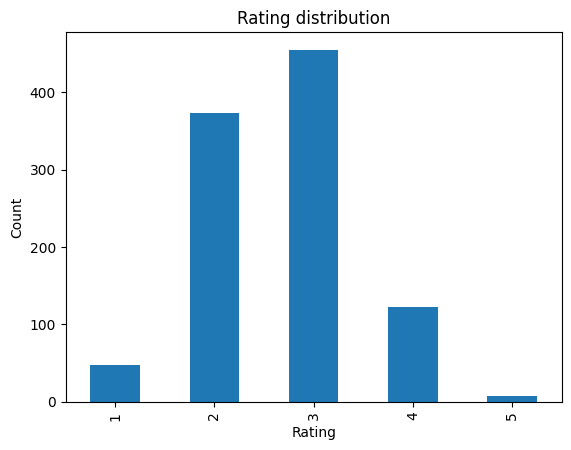

In [5]:
ratings_df['rating'].value_counts().sort_index().plot(kind='bar', title='Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

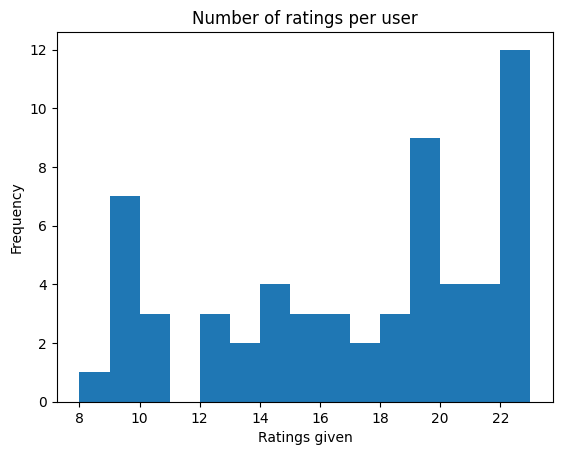

In [6]:
ratings_per_user = ratings_df.groupby('user_id').size()
ratings_per_user.plot(kind='hist', bins=15, title='Number of ratings per user')
plt.xlabel('Ratings given')
plt.show()

## Step 3 — Build the User-Item Matrix
Collaborative filtering needs data reshaped into a matrix: rows = users, columns = movies,
cells = ratings (empty = not yet rated). This is the "wide format".

In [7]:
matrix = build_user_item_matrix(ratings_df)
print("Matrix shape (users x movies):", matrix.shape)
matrix.iloc[:8, :8]  # peek at a small corner -- most cells are empty (NaN), and that's normal

Matrix shape (users x movies): (60, 45)


movie_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,3.0,NaN,NaN,3.0,2.0,NaN,NaN,NaN
2,2.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,4.0,NaN,3.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
5,NaN,4.0,3.0,4.0,NaN,2.0,2.0,NaN
6,2.0,NaN,2.0,NaN,3.0,NaN,1.0,3.0
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,3.0,NaN,NaN,NaN,4.0,NaN


## Step 4 — Train / Test Split
For recommenders, we hide ~20% of EACH user's ratings as the test set, and train on
the rest. This simulates the real task: "predict ratings the user hasn't given yet."


In [8]:
train_df, test_df = train_test_split_per_user(ratings_df, test_fraction=0.2)
print(f"Train: {len(train_df)} ratings | Test: {len(test_df)} ratings")

Train: 832 ratings | Test: 172 ratings


## Step 5 — Design & Train the Algorithm

**User-Based Collaborative Filtering, step by step:**
1. Build the user-item matrix from the TRAINING data only
2. Mean-center each user's ratings (removes the bias of users who always rate high/low)
3. Compute cosine similarity between every pair of users
4. To predict a rating: take a similarity-weighted average of the rating that a
   user's most similar neighbors gave to that movie

`k_neighbors` is the main hyperparameter — how many similar users to "listen to"
when making a prediction.

In [9]:
model = UserBasedCF(k_neighbors=10)
model.fit(train_df)
print("Trained! User-item matrix shape:", model.user_item_matrix.shape)

# Peek at the similarity between a couple of users
model.user_similarity.iloc[:5, :5]

Trained! User-item matrix shape: (60, 45)


user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,-0.301329,-0.060502,0.021870,0.055264
2,-0.301329,1.000000,-0.225578,-0.012302,-0.273103
3,-0.060502,-0.225578,1.000000,0.224415,0.201761
4,0.021870,-0.012302,0.224415,1.000000,0.338421
5,0.055264,-0.273103,0.201761,0.338421,1.000000


## Step 6 — Baseline Model (for comparison)
Before trusting the main model, we ALWAYS compare it against something simple.
Here, the baseline just recommends the movies with the highest average rating
to everyone — it ignores individual taste completely.

In [10]:
baseline = PopularityRecommender(min_ratings=3)
baseline.fit(train_df)
print("Baseline trained. Top 5 most popular movies overall:")
baseline.ranked_movies.head()

Baseline trained. Top 5 most popular movies overall:


,mean,count
movie_id,,
27,3.111111,18
38,3.071429,14
6,3.050000,20
14,3.000000,23
28,2.944444,18


## Step 7 — Test / Validate on Unseen Data
We now predict ratings for the TEST set (which the model never saw during training)
and compare the predictions to the real ratings.

In [11]:
sample_row = test_df.iloc[0]
predicted = model.predict(sample_row['user_id'], sample_row['movie_id'])
print(f"User {sample_row['user_id']} rated movie {sample_row['movie_id']} = {sample_row['rating']}")
print(f"Model predicted: {predicted:.2f}")

User 1 rated movie 22 = 3
Model predicted: 2.25


## Step 8 — Measure Performance

Two families of metrics:
- **RMSE / MAE** — how close were the predicted rating *numbers*?
- **Precision@K / Recall@K** — did we recommend the *right movies*?

In [12]:
results = print_evaluation_report(model, train_df, test_df, movies_df, k=5)

===== MODEL EVALUATION REPORT =====


RMSE (rating prediction error) : 0.752  (lower is better, scale 1-5)
MAE  (rating prediction error) : 0.609  (lower is better, scale 1-5)


Precision@5 (top-5 recs that were actually liked) : 0.060
Recall@5    (liked movies captured in top-5)       : 0.300


In [13]:
# Compare against baseline RMSE/MAE
def simple_rmse_mae(m, test_df):
    errs = [m.predict(r.user_id, r.movie_id) - r.rating for r in test_df.itertuples()]
    errs = np.array(errs)
    return np.sqrt((errs**2).mean()), np.abs(errs).mean()

b_rmse, b_mae = simple_rmse_mae(baseline, test_df)

comparison = pd.DataFrame({
    'Model': ['Baseline (Popularity)', 'Collaborative Filtering'],
    'RMSE': [b_rmse, results['rmse']],
    'MAE': [b_mae, results['mae']],
})
comparison

,Model,RMSE,MAE
0,Baseline (Popularity),0.774660,0.632297
1,Collaborative Filtering,0.752266,0.608687


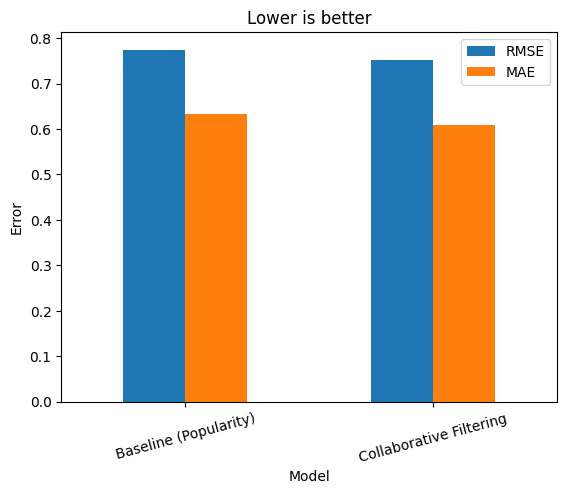

In [14]:
comparison.plot(x='Model', y=['RMSE', 'MAE'], kind='bar', title='Lower is better')
plt.ylabel('Error')
plt.xticks(rotation=15)
plt.show()

## Step 9 — Use the Trained Model: Generate Real Recommendations
This is the final output your users would actually see.

In [15]:
sample_user = train_df['user_id'].iloc[0]
recommendations = model.recommend(sample_user, movies_df, top_n=5)
print(f"Top 5 recommended movies for User {sample_user}:")
recommendations

Top 5 recommended movies for User 1:


,title,genre,predicted_rating
0,Laugh Track,Comedy,3.477387
1,The Prank,Comedy,3.224235
2,The Divorce,SciFi,3.221323
3,Stand-Up Nights,SciFi,3.194868
4,Tank Battalion,Comedy,3.162238


## Step 10 — Try It Yourself
Change `sample_user` below and re-run to see recommendations for a different user.
Try changing `k_neighbors` in Step 5 (e.g., 3 vs 20) and re-running the evaluation —
observe how RMSE/MAE and Precision/Recall change. This is called **hyperparameter tuning**.

In [16]:
# Try a different user
another_user = 15
model.recommend(another_user, movies_df, top_n=5)

,title,genre,predicted_rating
0,First Kiss,Action,3.024947
1,Battle Zone,Action,3.020801
2,Star Voyage,Comedy,3.014412
3,Explosive Chase,SciFi,2.846556
4,Rogue Squad,SciFi,2.798442


## Summary — What We Did (mapped to the standard ML pipeline)

| Step | What we did | Code |
|---|---|---|
| 1. Load | Read raw CSV ratings | `data_loader.py` |
| 2. Explore | Checked sparsity, rating distribution | `basic_stats()` |
| 3. Prepare | Reshaped into user-item matrix | `build_user_item_matrix()` |
| 4. Split | Held out 20% of each user's ratings | `train_test_split_per_user()` |
| 5. Design/Train | Cosine-similarity user-based CF | `UserBasedCF.fit()` |
| 6. Baseline | Popularity-based recommender | `PopularityRecommender` |
| 7. Test | Predicted ratings on unseen data | `model.predict()` |
| 8. Measure | RMSE, MAE, Precision@K, Recall@K | `evaluate.py` |
| 9. Deploy | Generated top-N recommendations | `model.recommend()` |

**Next steps for students:** try item-based CF (swap users and movies), try
matrix factorization (SVD) with `scikit-surprise`, or try a hybrid model that
also uses movie genres as content-based features.
